<a href="https://colab.research.google.com/github/La-rra/CODSOFT_TASK5/blob/main/CODESOFT_TASK5_HANDWRITTEN_TEXT_GENERATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import zipfile, os

In [ ]:

print("Upload the dataset as a ZIP file (containing english.csv + Img folder)")
uploaded = files.upload()

Upload the dataset as a ZIP file (containing english.csv + Img folder)


Saving handwritten-text-generation.ipynb to handwritten-text-generation.ipynb


In [ ]:
for fname in uploaded:
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname, 'r') as z:
               z.extractall('data')
        print(f"Extracted {fname} into 'data/'")

In [ ]:
csv_path = None
img_base = None

for root, dirs, filenames in os.walk('.'):
    for f in filenames:
         if f.lower() == 'english.csv':
             csv_path = os.path.join(root, f)
             img_base = root

if csv_path is None:
     raise FileNotFoundError("Could not find english.csv anywhere. Check your upload/zip.")

print("Found CSV at:", csv_path)
print("Image base folder:", img_base)


FileNotFoundError: Could not find english.csv anywhere. Check your upload/zip.

In [ ]:
import os

print("Files/folders in current directory:")
for item in os.listdir('.'):
    print(" -", item)

print("\nFull recursive listing:")
for root, dirs, filenames in os.walk('.'):
        # skip Colab's internal sample_data folder to reduce noise
    if 'sample_data' in root:
         continue
    for f in filenames:
         print(os.path.join(root, f))

Files/folders in current directory:
 - .config
 - handwritten-text-generation.ipynb
 - sample_data

Full recursive listing:
./handwritten-text-generation.ipynb
./.config/.last_survey_prompt.yaml
./.config/gce
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/default_configs.db
./.config/.last_opt_in_prompt.yaml
./.config/config_sentinel
./.config/.last_update_check.json
./.config/active_config
./.config/configurations/config_default
./.config/logs/2026.08.10/13.25.25.328016.log
./.config/logs/2026.08.10/13.26.03.888211.log
./.config/logs/2026.08.10/13.26.19.834999.log
./.config/logs/2026.08.10/13.25.43.233148.log
./.config/logs/2026.08.10/13.24.58.373513.log
./.config/logs/2026.08.10/13.26.18.998373.log


In [ ]:
from google.colab import files
import zipfile, os

print("Select the dataset ZIP file (must contain english.csv + Img folder inside)")
uploaded = files.upload()

print("\nUploaded:", list(uploaded.keys()))

for fname in uploaded:
    if fname.endswith('.zip'):
            with zipfile.ZipFile(fname, 'r') as z:
                        z.extractall('data')
                        print(f"Extracted {fname} into 'data/'")
    else:
        print(f"WARNING: '{fname}' is not a .zip file — it won't be extracted.")

Select the dataset ZIP file (must contain english.csv + Img folder inside)


Saving archive (3).zip to archive (3).zip

Uploaded: ['archive (3).zip']
Extracted archive (3).zip into 'data/'


In [ ]:
csv_path = None
img_base = None

for root, dirs, filenames in os.walk('data'):
    for f in filenames:
            if f.lower() == 'english.csv':
                        csv_path = os.path.join(root, f)
                        img_base = root

            if csv_path is None:
                    raise FileNotFoundError("Could not find english.csv inside 'data/'. Re-check Cell 1.")

print("Found CSV at:", csv_path)
print("Image base folder:", img_base)

Found CSV at: data/english.csv
Image base folder: data


In [ ]:
import pandas as pd
import numpy as np
from PIL import Image

df = pd.read_csv(csv_path)
print(df.shape)
print(df['label'].value_counts())
print("Nulls:", df.isna().sum().sum(), "Duplicates:", df.duplicated().sum())

IMG_SIZE = 100

images = []
for path in df['image']:
    full_path = os.path.join(img_base, path)
    img = Image.open(full_path).convert('L')
    img = img.resize((IMG_SIZE, IMG_SIZE))
    images.append(np.array(img))

image_data = np.array(images, dtype='float32') / 255.0
print("Image data shape:", image_data.shape)

(3410, 2)
label
0    55
1    55
2    55
3    55
4    55
     ..
v    55
w    55
x    55
y    55
z    55
Name: count, Length: 62, dtype: int64
Nulls: 0 Duplicates: 0
Image data shape: (3410, 100, 100)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

tokenizer = tf.keras.preprocessing.text.Tokenizer(char_level=True, lower=False)
tokenizer.fit_on_texts(df['label'])
sequences = tokenizer.texts_to_sequences(df['label'])
sequences = np.array([s[0] for s in sequences])

vocab_size = len(tokenizer.word_index) + 1
print("Vocab size:", vocab_size)

Vocab size: 63


In [ ]:
from sklearn.model_selection import train_test_split
sequences_reshaped = sequences.reshape(-1, 1)

X_train, X_val, y_train, y_val = train_test_split(
    sequences_reshaped, image_data, test_size=0.15, random_state=42
        )

print("X_train shape:", X_train.shape)

X_train shape: (2898, 1)


In [ ]:
model = models.Sequential([
      layers.Input(shape=(1,)),
      layers.Embedding(input_dim=vocab_size, output_dim=64),  # output: (batch, 1, 64)
      layers.LSTM(256),
      layers.Dense(512, activation='relu'),
      layers.Dropout(0.3),
      layers.Dense(IMG_SIZE * IMG_SIZE, activation='sigmoid'),
      layers.Reshape((IMG_SIZE, IMG_SIZE, 1))
                              ])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()




Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 1, 64)          │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 256)            │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10000)          │     5,130,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 100, 100, 1)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,594,320 (21.34 MB)

 Trainable params: 5,594,320 (21.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
      monitor='val_loss', patience=8, restore_best_weights=True)


history = model.fit(
      X_train, y_train,
      validation_data=(X_val, y_val),
      epochs=100,
      batch_size=32,
      callbacks=[early_stop]
                          )


Epoch 1/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 0.1251 - mae: 0.2676 - val_loss: 0.0381 - val_mae: 0.0725
Epoch 2/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.0388 - mae: 0.0784 - val_loss: 0.0372 - val_mae: 0.0804
Epoch 3/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - loss: 0.0384 - mae: 0.0825 - val_loss: 0.0372 - val_mae: 0.0797
Epoch 4/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0384 - mae: 0.0822 - val_loss: 0.0371 - val_mae: 0.0808
Epoch 5/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.0383 - mae: 0.0821 - val_loss: 0.0371 - val_mae: 0.0802
Epoch 6/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - loss: 0.0383 - mae: 0.0815 - val_loss: 0.0372 - val_mae: 0.0802
Epoch 7/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 13s 147ms/step - loss: 0.0382 - mae: 0.0815 - val_loss: 0.0372 - val_mae: 0.0790
Epoch 8/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - loss: 0.0382 - mae: 0.0813 - val_loss: 0.0370 - val_mae: 0.0808
Epoch 9/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 20s 11

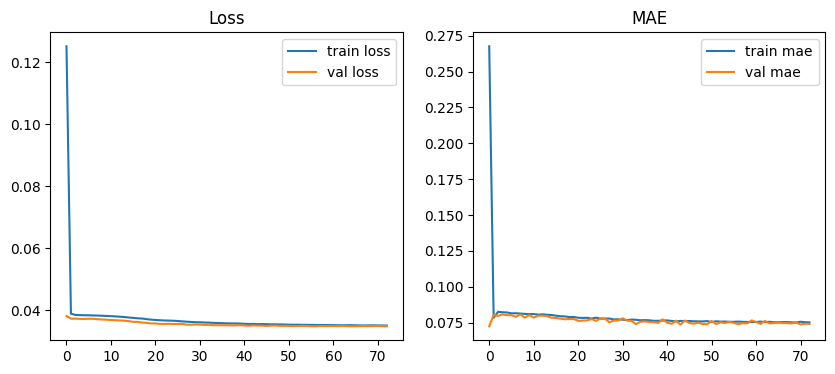

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(); plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='train mae')
plt.plot(history.history['val_mae'], label='val mae')
plt.legend(); plt.title('MAE')
plt.show()

In [ ]:
def generate_text_image(text, char_gap=5):
      chars = list(text)
      char_images = []
      for ch in chars:
         if ch == " ":
              char_images.append(np.ones((IMG_SIZE, IMG_SIZE)))
         else:
              seq = tokenizer.texts_to_sequences([ch])[0]
              if not seq:
                   char_images.append(np.ones((IMG_SIZE, IMG_SIZE)))  # unknown char
                   continue
              seq = np.array(seq).reshape(1, 1)
              pred = model.predict(seq, verbose=0)[0].reshape(IMG_SIZE, IMG_SIZE)
              char_images.append(pred)
         char_images.append(np.ones((IMG_SIZE, char_gap)))

      full_image = np.hstack(char_images)
      plt.figure(figsize=(len(chars) * 0.8, 2))
      plt.imshow(full_image, cmap='gray')
      plt.axis('off')
      plt.show()

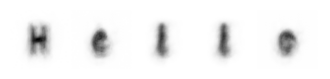

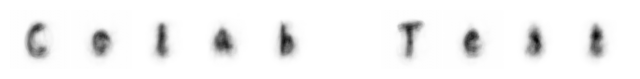

In [ ]:
generate_text_image("Hello")
generate_text_image("Colab Test")

In [ ]:
model.save('handwriting_model.h5')
print("Model saved as handwriting_model.h5")

Model saved as handwriting_model.h5
